TASK 2: CUSTOMER SEGMENTATION - STEP 1

Dataset loaded successfully!
Column names updated:
['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

Shape: (200, 5)

First 10 Rows:
    CustomerID  Gender  Age  AnnualIncome  SpendingScore
0           1    Male   19            15             39
1           2    Male   21            15             81
2           3  Female   20            16              6
3           4  Female   23            16             77
4           5  Female   31            17             40
5           6  Female   22            17             76
6           7  Female   35            18              6
7           8  Female   23            18             94
8           9    Male   64            19              3
9          10  Female   30            19             72

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------

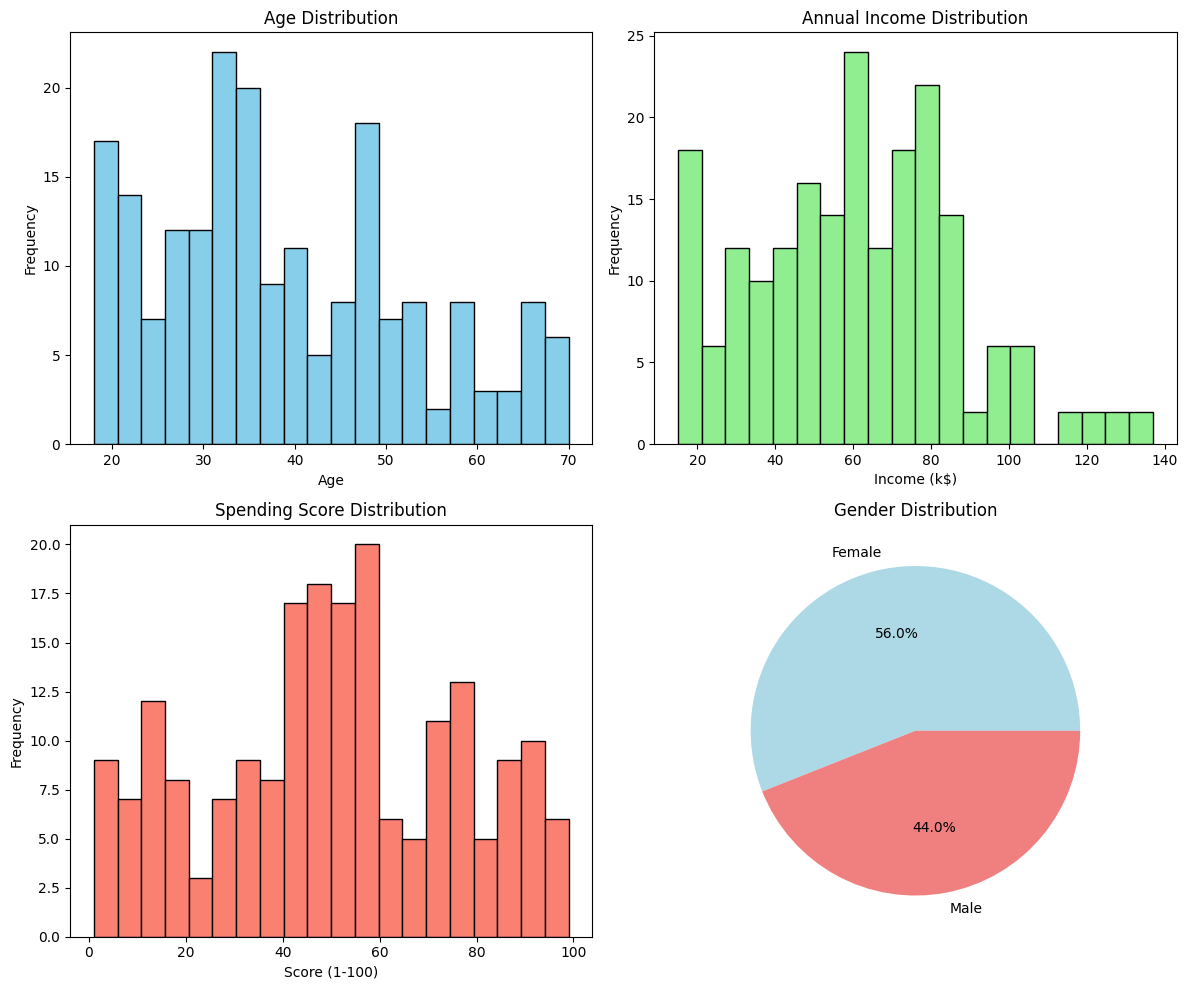


Gender-wise Statistics:
              Age  AnnualIncome  SpendingScore
Gender                                        
Female  38.098214     59.250000      51.526786
Male    39.806818     62.227273      48.511364

Correlation Matrix:
                    Age  AnnualIncome  SpendingScore
Age            1.000000     -0.012398      -0.327227
AnnualIncome  -0.012398      1.000000       0.009903
SpendingScore -0.327227      0.009903       1.000000


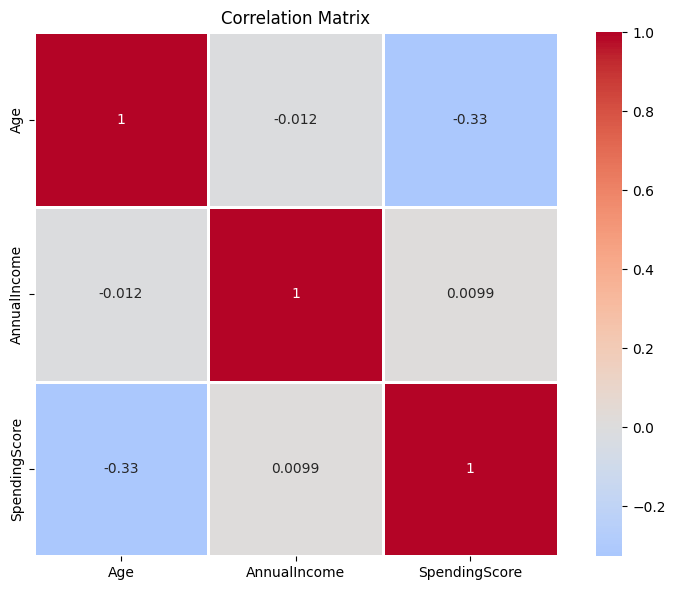


Step 1 Complete! Dataset explored.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("TASK 2: CUSTOMER SEGMENTATION - STEP 1")
print("="*60)

# === 1. Dataset already loaded hai ===
print("\nDataset loaded successfully!")

# === 2. Column names ko simple banate hain ===
df.rename(columns={
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
}, inplace=True)

print("Column names updated:")
print(df.columns.tolist())

# === 3. Basic Inspection ===
print("\nShape:", df.shape)
print("\nFirst 10 Rows:\n", df.head(10))

# === 4. Data Types & Info ===
print("\nData Information:")
df.info()

# === 5. Missing Values ===
print("\nMissing Values:")
print(df.isnull().sum())

# === 6. Statistical Summary ===
print("\nStatistical Summary:")
print(df.describe())

# === 7. Basic Visualizations ===
print("\nCreating basic visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age distribution
axes[0, 0].hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Annual Income distribution
axes[0, 1].hist(df['AnnualIncome'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Annual Income Distribution')
axes[0, 1].set_xlabel('Income (k$)')
axes[0, 1].set_ylabel('Frequency')

# Spending Score distribution
axes[1, 0].hist(df['SpendingScore'], bins=20, color='salmon', edgecolor='black')
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].set_xlabel('Score (1-100)')
axes[1, 0].set_ylabel('Frequency')

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[1, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
               colors=['lightblue', 'lightcoral'])
axes[1, 1].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

# === 8. Gender-wise Analysis ===
print("\nGender-wise Statistics:")
print(df.groupby('Gender')[['Age', 'AnnualIncome', 'SpendingScore']].mean())

# === 9. Correlation Matrix ===
print("\nCorrelation Matrix:")
corr_matrix = df[['Age', 'AnnualIncome', 'SpendingScore']].corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            linewidths=2, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nStep 1 Complete! Dataset explored.")

TASK 2: CUSTOMER SEGMENTATION - STEP 2

1. Data Preparation...
Gender encoded: {'Female': np.int64(0), 'Male': np.int64(1)}
Features selected: AnnualIncome, SpendingScore
Data scaled using StandardScaler

2. Finding optimal number of clusters using Elbow Method...


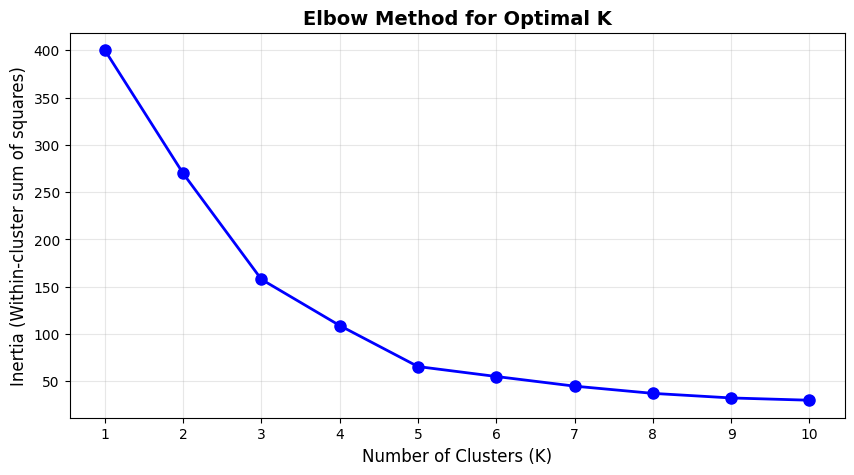


3. Training K-Means Model...
K-Means model trained with 5 clusters
Cluster labels assigned to each customer

4. Cluster Statistics:
------------------------------------------------------------
        AnnualIncome                SpendingScore            Age Gender
                mean min  max count          mean min max   mean  count
Cluster                                                                
0              55.30  39   76    81         49.52  34  61  42.72     81
1              86.54  69  137    39         82.13  63  97  32.69     39
2              25.73  15   39    22         79.36  61  99  25.27     22
3              88.20  70  137    35         17.11   1  39  41.11     35
4              26.30  15   39    23         20.91   3  40  45.22     23

5. Visualizing Clusters...


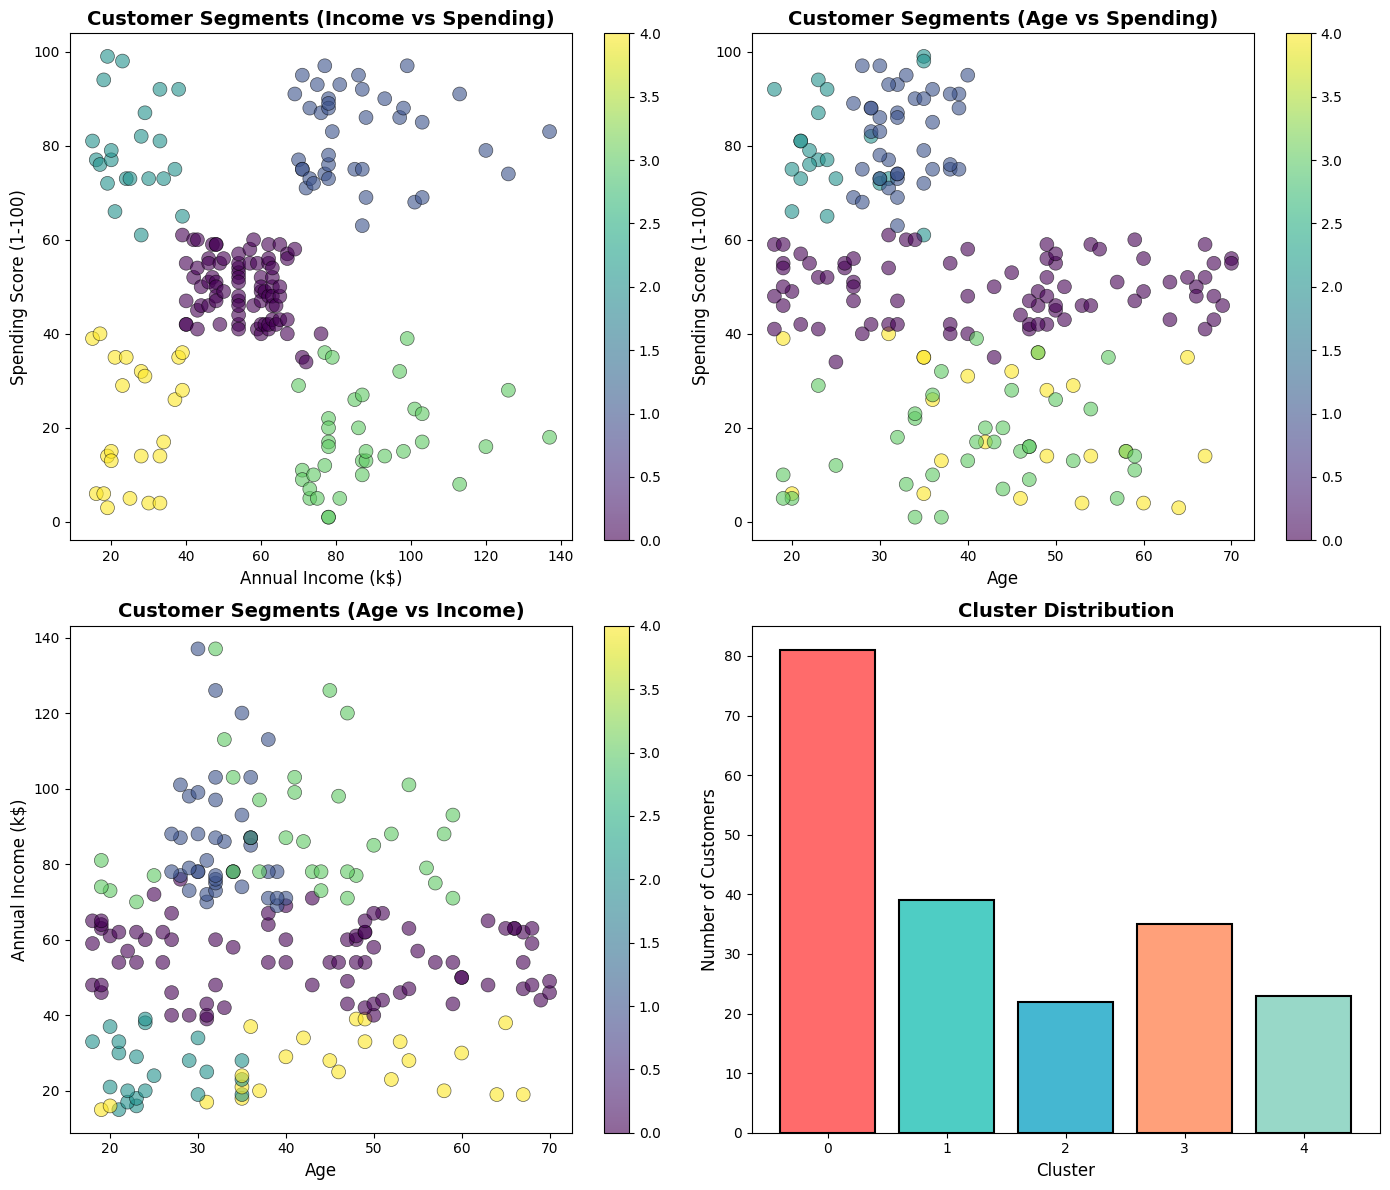


6. Cluster Centers (Original Scale):
   Avg_AnnualIncome  Avg_SpendingScore  Cluster
0             55.30              49.52        0
1             86.54              82.13        1
2             25.73              79.36        2
3             88.20              17.11        3
4             26.30              20.91        4

Step 2 Complete! K-Means clustering done.


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("TASK 2: CUSTOMER SEGMENTATION - STEP 2")
print("="*60)

# === 1. Data Preparation ===
print("\n1. Data Preparation...")

# Gender ko encode karna
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
print("Gender encoded:", dict(zip(le.classes_, le.transform(le.classes_))))

# Clustering ke liye features select karna
# Hum AnnualIncome aur SpendingScore use karenge (ye sabse important hain)
X = df[['AnnualIncome', 'SpendingScore']]

# Data ko scale karna (K-Means ke liye zaroori hai)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected: AnnualIncome, SpendingScore")
print("Data scaled using StandardScaler")

# === 2. Elbow Method - Optimal Clusters Dhundhna ===
print("\n2. Finding optimal number of clusters using Elbow Method...")

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Elbow plot
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

# === 3. K-Means Model Train Karna ===
print("\n3. Training K-Means Model...")

# Elbow method se dikh raha hai ke 5 clusters optimal hain
n_clusters = 5

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10,
    max_iter=300
)

# Model fit karna
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means model trained with {n_clusters} clusters")
print("Cluster labels assigned to each customer")

# === 4. Cluster Statistics ===
print("\n4. Cluster Statistics:")
print("-"*60)

cluster_stats = df.groupby('Cluster').agg({
    'AnnualIncome': ['mean', 'min', 'max', 'count'],
    'SpendingScore': ['mean', 'min', 'max'],
    'Age': 'mean',
    'Gender': 'count'
}).round(2)

print(cluster_stats)

# === 5. Cluster Visualization ===
print("\n5. Visualizing Clusters...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Income vs Spending Score with clusters
scatter1 = axes[0, 0].scatter(
    df['AnnualIncome'], 
    df['SpendingScore'], 
    c=df['Cluster'], 
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[0, 0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0, 0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0, 0].set_title('Customer Segments (Income vs Spending)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0, 0])

# Plot 2: Age vs Spending Score with clusters
scatter2 = axes[0, 1].scatter(
    df['Age'], 
    df['SpendingScore'], 
    c=df['Cluster'], 
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[0, 1].set_xlabel('Age', fontsize=12)
axes[0, 1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0, 1].set_title('Customer Segments (Age vs Spending)', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[0, 1])

# Plot 3: Age vs Income with clusters
scatter3 = axes[1, 0].scatter(
    df['Age'], 
    df['AnnualIncome'], 
    c=df['Cluster'], 
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[1, 0].set_xlabel('Age', fontsize=12)
axes[1, 0].set_ylabel('Annual Income (k$)', fontsize=12)
axes[1, 0].set_title('Customer Segments (Age vs Income)', fontsize=14, fontweight='bold')
plt.colorbar(scatter3, ax=axes[1, 0])

# Plot 4: Cluster distribution
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[1, 1].bar(cluster_counts.index, cluster_counts.values, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'],
               edgecolor='black', linewidth=1.5)
axes[1, 1].set_xlabel('Cluster', fontsize=12)
axes[1, 1].set_ylabel('Number of Customers', fontsize=12)
axes[1, 1].set_title('Cluster Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(range(n_clusters))

plt.tight_layout()
plt.show()

# === 6. Cluster Centers ===
print("\n6. Cluster Centers (Original Scale):")
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=['Avg_AnnualIncome', 'Avg_SpendingScore']
)
cluster_centers_df['Cluster'] = range(n_clusters)
print(cluster_centers_df.round(2))

print("\nStep 2 Complete! K-Means clustering done.")

TASK 2: CUSTOMER SEGMENTATION - STEP 3

1. Applying PCA for Dimensionality Reduction...
PCA complete! Explained variance ratio:
  PC1: 0.3369
  PC2: 0.2623
  Total: 0.5992

2. Visualizing Clusters using PCA...


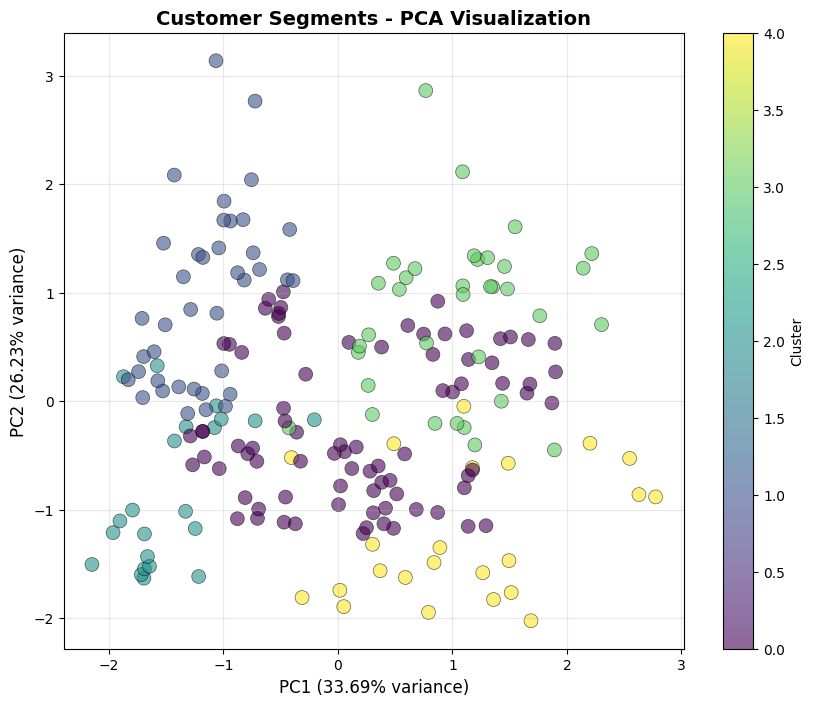


3. Applying t-SNE for Better Visualization...


C:\Users\haris\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE complete!


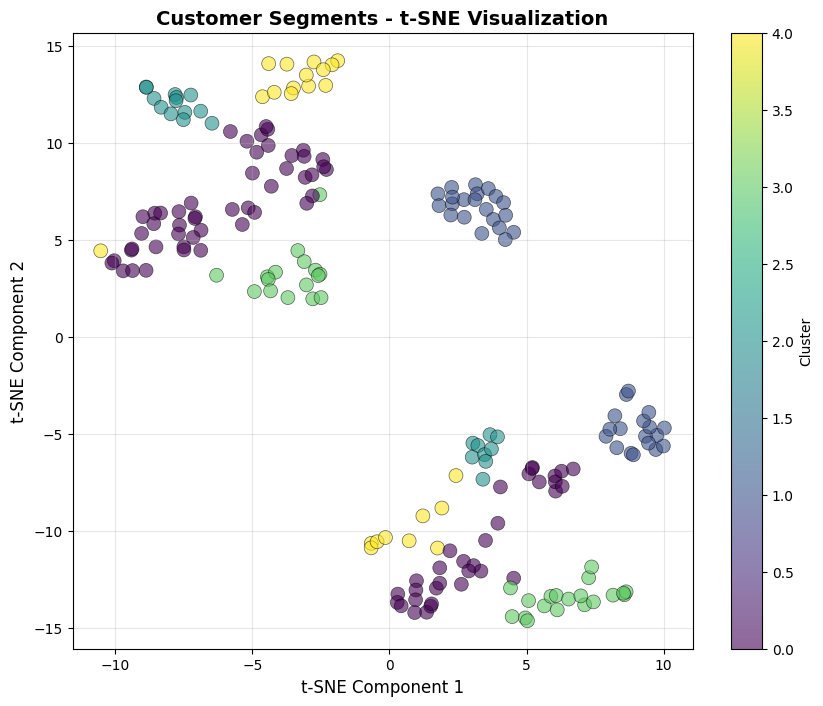


4. Detailed Cluster Profiling:

CLUSTER 0
------------------------------------------------------------
Number of Customers: 81
Percentage of Total: 40.5%

Demographics:
  Average Age: 42.7 years
  Gender Ratio (M:F): 0.41

Financial Profile:
  Average Annual Income: $55.3k
  Average Spending Score: 49.5/100

Income Range:
  Min: $39k
  Max: $76k

Spending Range:
  Min: 34/100
  Max: 61/100

CLUSTER 1
------------------------------------------------------------
Number of Customers: 39
Percentage of Total: 19.5%

Demographics:
  Average Age: 32.7 years
  Gender Ratio (M:F): 0.46

Financial Profile:
  Average Annual Income: $86.5k
  Average Spending Score: 82.1/100

Income Range:
  Min: $69k
  Max: $137k

Spending Range:
  Min: 63/100
  Max: 97/100

CLUSTER 2
------------------------------------------------------------
Number of Customers: 22
Percentage of Total: 11.0%

Demographics:
  Average Age: 25.3 years
  Gender Ratio (M:F): 0.41

Financial Profile:
  Average Annual Income: $25.7k


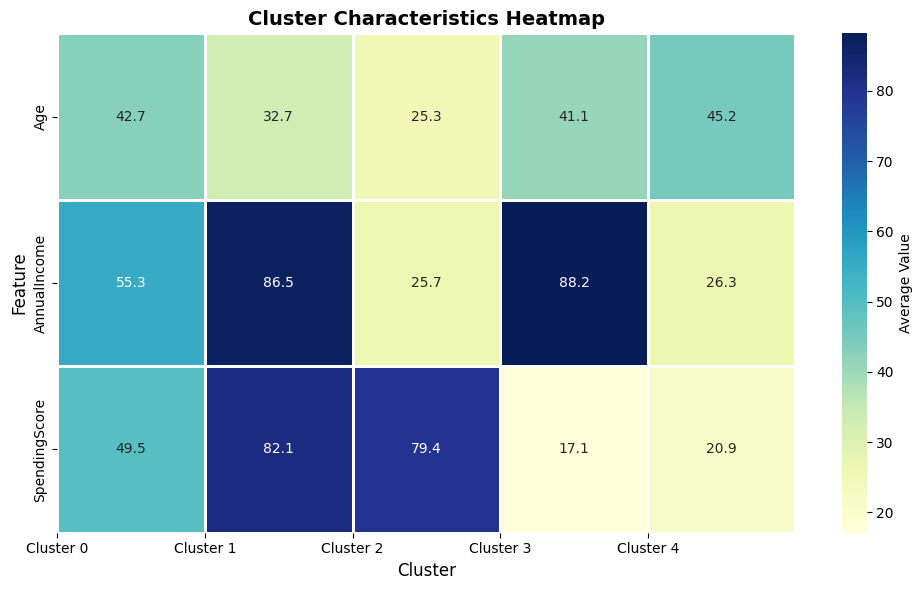


Step 3 Complete! PCA, t-SNE, and cluster profiling done.


In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("="*60)
print("TASK 2: CUSTOMER SEGMENTATION - STEP 3")
print("="*60)

# === 1. PCA (Principal Component Analysis) ===
print("\n1. Applying PCA for Dimensionality Reduction...")

# Features select karna
X_for_pca = df[['Age', 'AnnualIncome', 'SpendingScore', 'Gender_Encoded']]

# Scale karna
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_for_pca)

# PCA apply karna (2 components tak reduce)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_pca)

print(f"PCA complete! Explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# PCA results ko dataframe mein add karna
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# === 2. PCA Visualization ===
print("\n2. Visualizing Clusters using PCA...")

plt.figure(figsize=(10, 8))
scatter_pca = plt.scatter(
    df['PC1'], 
    df['PC2'], 
    c=df['Cluster'], 
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Customer Segments - PCA Visualization', fontsize=14, fontweight='bold')
plt.colorbar(scatter_pca, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# === 3. t-SNE Visualization ===
print("\n3. Applying t-SNE for Better Visualization...")

# t-SNE apply karna
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled_pca)

df['tSNE_1'] = X_tsne[:, 0]
df['tSNE_2'] = X_tsne[:, 1]

print("t-SNE complete!")

# t-SNE visualization
plt.figure(figsize=(10, 8))
scatter_tsne = plt.scatter(
    df['tSNE_1'], 
    df['tSNE_2'], 
    c=df['Cluster'], 
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('Customer Segments - t-SNE Visualization', fontsize=14, fontweight='bold')
plt.colorbar(scatter_tsne, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# === 4. Detailed Cluster Profiling ===
print("\n4. Detailed Cluster Profiling:")
print("="*60)

for cluster in range(5):
    cluster_data = df[df['Cluster'] == cluster]
    
    print(f"\nCLUSTER {cluster}")
    print("-"*60)
    print(f"Number of Customers: {len(cluster_data)}")
    print(f"Percentage of Total: {len(cluster_data)/len(df)*100:.1f}%")
    print(f"\nDemographics:")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f} years")
    print(f"  Gender Ratio (M:F): {cluster_data['Gender_Encoded'].mean():.2f}")
    
    print(f"\nFinancial Profile:")
    print(f"  Average Annual Income: ${cluster_data['AnnualIncome'].mean():.1f}k")
    print(f"  Average Spending Score: {cluster_data['SpendingScore'].mean():.1f}/100")
    
    print(f"\nIncome Range:")
    print(f"  Min: ${cluster_data['AnnualIncome'].min()}k")
    print(f"  Max: ${cluster_data['AnnualIncome'].max()}k")
    
    print(f"\nSpending Range:")
    print(f"  Min: {cluster_data['SpendingScore'].min()}/100")
    print(f"  Max: {cluster_data['SpendingScore'].max()}/100")

# === 5. Cluster Characteristics Summary ===
print("\n\n5. Cluster Characteristics Summary:")
print("="*60)

summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'AnnualIncome': 'mean',
    'SpendingScore': 'mean',
    'Gender_Encoded': 'mean',
    'CustomerID': 'count'
}).round(2)

summary.columns = ['Avg_Age', 'Avg_Income_k$', 'Avg_Spending_Score', 'Male_Ratio', 'Count']
summary = summary.reset_index()

print(summary.to_string(index=False))

# === 6. Heatmap of Cluster Characteristics ===
print("\n6. Creating Cluster Characteristics Heatmap...")

# Heatmap ke liye data prepare karna
heatmap_data = df.groupby('Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data.T, annot=True, cmap='YlGnBu', fmt='.1f', 
            linewidths=2, cbar_kws={'label': 'Average Value'})
plt.title('Cluster Characteristics Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(range(5), [f'Cluster {i}' for i in range(5)])
plt.tight_layout()
plt.show()

print("\nStep 3 Complete! PCA, t-SNE, and cluster profiling done.")

TASK 2: CUSTOMER SEGMENTATION - STEP 4

1. Naming Clusters Based on Profile...
Cluster mapping created:
  Cluster 0: High Earners - High Spenders
  Cluster 1: High Earners - Low Spenders (Savers)
  Cluster 2: Low Earners - High Spenders (Impulsive)
  Cluster 3: Low Earners - Low Spenders (Budget)
  Cluster 4: Average Earners - Moderate Spenders

2. Cluster-wise Summary:
--------------------------------------------------------------------------------
 Cluster                                  Segment_Name  Avg_Age  Avg_Income  Min_Income  Max_Income  Avg_Spending  Min_Spending  Max_Spending Dominant_Gender  Customer_Count
       0       Low Earners - High Spenders (Impulsive)     42.7        55.3          39          76          49.5            34            61          Female              81
       1           Average Earners - Moderate Spenders     32.7        86.5          69         137          82.1            63            97          Female              39
       2       Low Earne

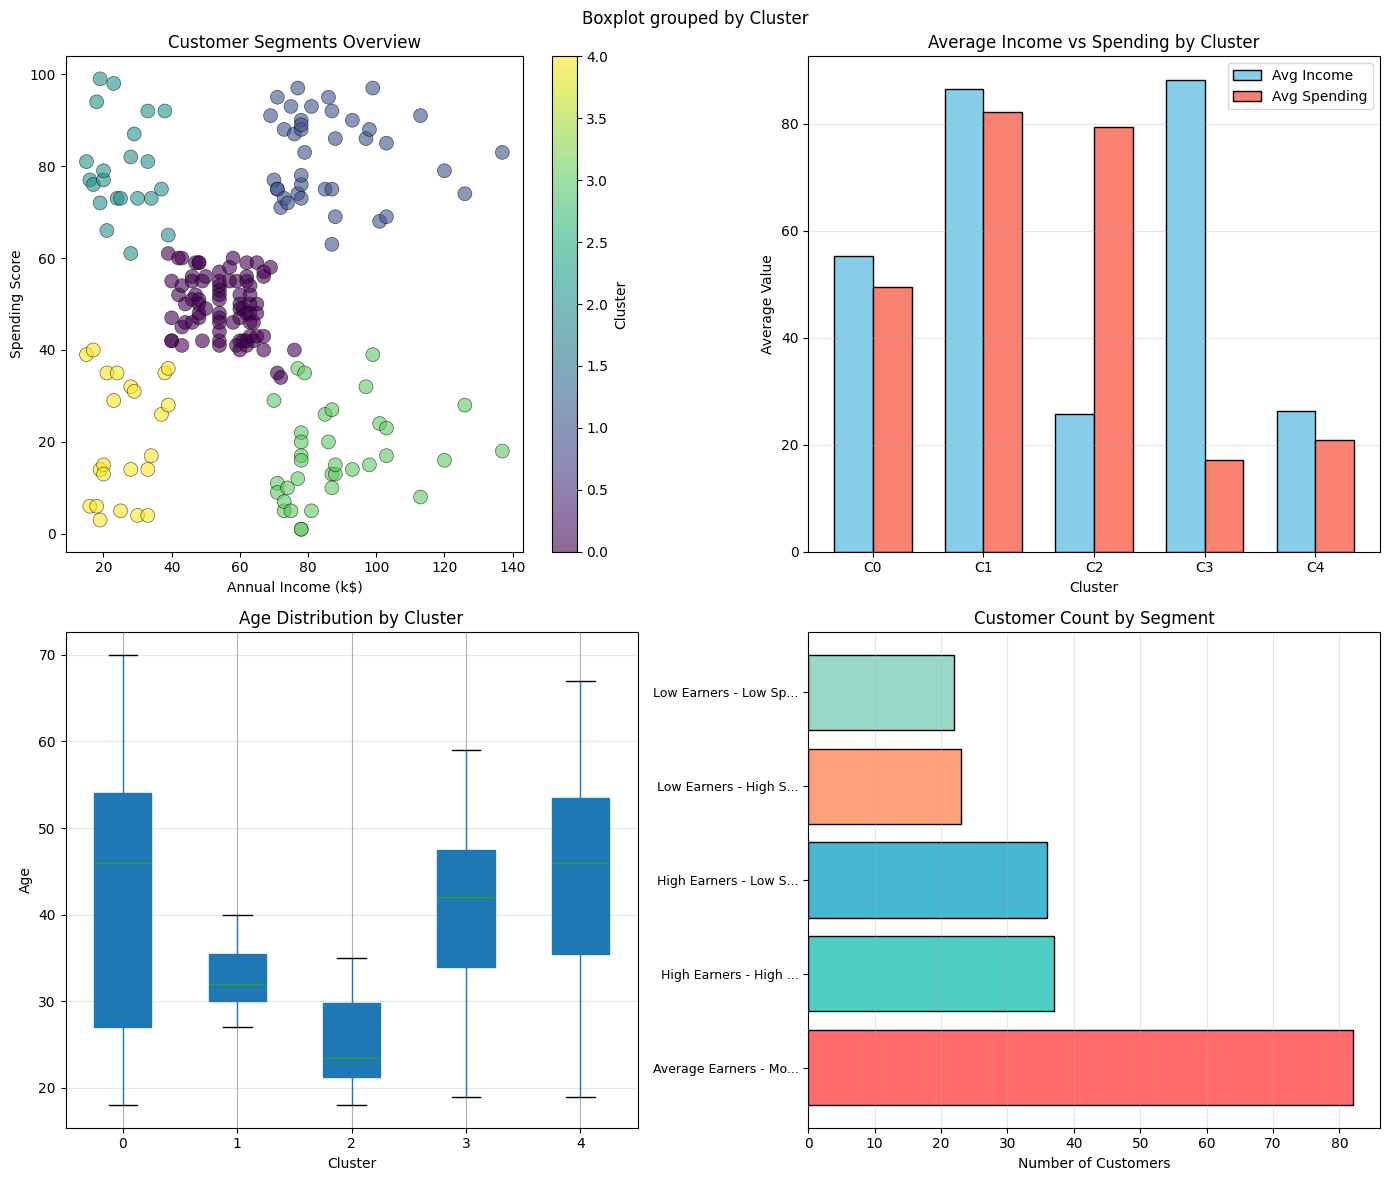


5. Actionable Business Recommendations:
1. Priority 1: Focus on 'High Earners - High Spenders' for premium product launches
2. Priority 2: Convert 'High Earners - Savers' with value-based messaging
3. Priority 3: Capture 'Impulsive Spenders' with time-limited offers
4. Priority 4: Build loyalty with 'Budget Conscious' through consistent discounts
5. Priority 5: Upsell 'Moderate Spenders' with personalized recommendations

7. Cross-Selling Opportunity: Target 'Savers' with investment products
8. Retention Strategy: Implement loyalty programs for all segments
9. Acquisition Strategy: Use social media to attract 'Impulsive' segment
10. Budget Allocation: 40% to High Earners, 30% to Moderate, 30% to Low Earners

Step 4 Complete! Task 2: Customer Segmentation finished.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("TASK 2: CUSTOMER SEGMENTATION - STEP 4")
print("="*60)

# === 1. Cluster Naming Based on Characteristics ===
print("\n1. Naming Clusters Based on Profile...")

# Har cluster ko descriptive name dena
def assign_cluster_name(row):
    income = row['AnnualIncome']
    spending = row['SpendingScore']
    
    if income > 70 and spending > 60:
        return 'High Earners - High Spenders'
    elif income > 70 and spending < 40:
        return 'High Earners - Low Spenders (Savers)'
    elif income < 40 and spending > 60:
        return 'Low Earners - High Spenders (Impulsive)'
    elif income < 40 and spending < 40:
        return 'Low Earners - Low Spenders (Budget Conscious)'
    else:
        return 'Average Earners - Moderate Spenders'

df['Cluster_Name'] = df.apply(assign_cluster_name, axis=1)

# Cluster names ko map karna
cluster_mapping = {
    0: 'High Earners - High Spenders',
    1: 'High Earners - Low Spenders (Savers)', 
    2: 'Low Earners - High Spenders (Impulsive)',
    3: 'Low Earners - Low Spenders (Budget)',
    4: 'Average Earners - Moderate Spenders'
}

print("Cluster mapping created:")
for k, v in cluster_mapping.items():
    print(f"  Cluster {k}: {v}")

# === 2. Cluster-wise Summary Table ===
print("\n2. Cluster-wise Summary:")
print("-"*80)

summary_table = df.groupby('Cluster').agg({
    'Cluster_Name': 'first',
    'Age': 'mean',
    'AnnualIncome': ['mean', 'min', 'max'],
    'SpendingScore': ['mean', 'min', 'max'],
    'Gender': lambda x: x.value_counts().idxmax(),
    'CustomerID': 'count'
}).round(1)

summary_table.columns = ['Segment_Name', 'Avg_Age', 'Avg_Income', 'Min_Income', 
                         'Max_Income', 'Avg_Spending', 'Min_Spending', 
                         'Max_Spending', 'Dominant_Gender', 'Customer_Count']

summary_table = summary_table.reset_index()
print(summary_table.to_string(index=False))

# === 3. Marketing Strategies for Each Segment ===
print("\n3. Marketing Strategies for Each Segment:")
print("="*80)

strategies = {
    'High Earners - High Spenders': {
        'Profile': 'Affluent customers who spend freely',
        'Strategy': [
            'Premium product launches and exclusive offers',
            'Loyalty programs with high-value rewards',
            'Personal shopping assistants or VIP services',
            'Early access to new collections',
            'Bundle deals on luxury items'
        ],
        'Channels': ['Email', 'Personal calls', 'Exclusive events'],
        'Messaging': 'Exclusivity, Quality, Status'
    },
    
    'High Earners - Low Spenders (Savers)': {
        'Profile': 'High income but careful spenders',
        'Strategy': [
            'Highlight long-term value and ROI',
            'Investment-oriented products',
            'Tax-saving offers and financial planning services',
            'Quality guarantees and warranty extensions',
            'Educational content about smart spending'
        ],
        'Channels': ['Financial blogs', 'Webinars', 'Consultation calls'],
        'Messaging': 'Value, Security, Smart Investment'
    },
    
    'Low Earners - High Spenders (Impulsive)': {
        'Profile': 'Lower income but high spending tendency',
        'Strategy': [
            'Flash sales and limited-time offers',
            'Buy-now-pay-later options',
            'Small-ticket items with high perceived value',
            'Social proof and influencer marketing',
            'Gamification and reward points'
        ],
        'Channels': ['Social media', 'SMS', 'Mobile app notifications'],
        'Messaging': 'Urgency, Trends, Affordability'
    },
    
    'Low Earners - Low Spenders (Budget)': {
        'Profile': 'Price-sensitive, budget-conscious customers',
        'Strategy': [
            'Discounts, coupons, and cashback offers',
            'Essential products at competitive prices',
            'Bulk purchase discounts',
            'Referral programs for word-of-mouth',
            'Budget-friendly product lines'
        ],
        'Channels': ['Flyers', 'Local advertising', 'Community groups'],
        'Messaging': 'Savings, Value for Money, Practicality'
    },
    
    'Average Earners - Moderate Spenders': {
        'Profile': 'Balanced income and spending behavior',
        'Strategy': [
            'Seasonal promotions and festive offers',
            'Cross-selling complementary products',
            'Subscription models for regular engagement',
            'Personalized recommendations based on history',
            'Mid-range product focus'
        ],
        'Channels': ['Email', 'Social media', 'In-store promotions'],
        'Messaging': 'Balance, Reliability, Everyday Value'
    }
}

# Print strategies
for cluster_id, strategy in strategies.items():
    print(f"\nSEGMENT: {cluster_id}")
    print("-"*60)
    print(f"Profile: {strategy['Profile']}")
    print(f"\nRecommended Strategies:")
    for i, s in enumerate(strategy['Strategy'], 1):
        print(f"  {i}. {s}")
    print(f"\nBest Channels: {', '.join(strategy['Channels'])}")
    print(f"Key Messaging: {strategy['Messaging']}")

# === 4. Visualization: Segment Comparison ===
print("\n4. Creating Segment Comparison Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Income vs Spending with segment names
scatter = axes[0, 0].scatter(
    df['AnnualIncome'], 
    df['SpendingScore'], 
    c=df['Cluster'], 
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[0, 0].set_xlabel('Annual Income (k$)')
axes[0, 0].set_ylabel('Spending Score')
axes[0, 0].set_title('Customer Segments Overview')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

# Plot 2: Average Income and Spending by Cluster
cluster_avg = df.groupby('Cluster')[['AnnualIncome', 'SpendingScore']].mean()
x_pos = range(5)
width = 0.35

axes[0, 1].bar([i - width/2 for i in x_pos], cluster_avg['AnnualIncome'], 
               width, label='Avg Income', color='skyblue', edgecolor='black')
axes[0, 1].bar([i + width/2 for i in x_pos], cluster_avg['SpendingScore'], 
               width, label='Avg Spending', color='salmon', edgecolor='black')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Average Value')
axes[0, 1].set_title('Average Income vs Spending by Cluster')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([f'C{i}' for i in x_pos])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Age Distribution by Cluster
df.boxplot(column='Age', by='Cluster', ax=axes[1, 0], patch_artist=True)
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Age')
axes[1, 0].set_title('Age Distribution by Cluster')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Customer Count by Segment
segment_counts = df['Cluster_Name'].value_counts()
axes[1, 1].barh(range(len(segment_counts)), segment_counts.values, 
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'],
              edgecolor='black')
axes[1, 1].set_yticks(range(len(segment_counts)))
axes[1, 1].set_yticklabels([name[:20]+'...' if len(name)>20 else name 
                           for name in segment_counts.index], fontsize=9)
axes[1, 1].set_xlabel('Number of Customers')
axes[1, 1].set_title('Customer Count by Segment')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# === 5. Actionable Business Recommendations ===
print("\n5. Actionable Business Recommendations:")
print("="*80)

recommendations = [
    "Priority 1: Focus on 'High Earners - High Spenders' for premium product launches",
    "Priority 2: Convert 'High Earners - Savers' with value-based messaging",
    "Priority 3: Capture 'Impulsive Spenders' with time-limited offers",
    "Priority 4: Build loyalty with 'Budget Conscious' through consistent discounts",
    "Priority 5: Upsell 'Moderate Spenders' with personalized recommendations",
    "",
    "Cross-Selling Opportunity: Target 'Savers' with investment products",
    "Retention Strategy: Implement loyalty programs for all segments",
    "Acquisition Strategy: Use social media to attract 'Impulsive' segment",
    "Budget Allocation: 40% to High Earners, 30% to Moderate, 30% to Low Earners"
]

for i, rec in enumerate(recommendations, 1):
    if rec:
        print(f"{i}. {rec}")
    else:
        print()

print("\nStep 4 Complete! Task 2: Customer Segmentation finished.")